## Datasets and imports

In [1]:
import os

# Store the current directory
current_directory = os.getcwd()
# Change to the parent directory only if not already in the parent
if os.path.basename(current_directory) != os.path.basename(os.path.abspath(os.path.join(current_directory, os.pardir))):
    os.chdir(os.pardir)

from src.utils import AIDatasetLoader, filter_by_app_and_model, DecisionTreeInterpreter, LogisticRegressionInterpreter  
from src.memory import Chunk, DeclarativeMemory

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time


In [2]:
current_dir = os.getcwd()
data_dir = os.path.join(current_dir, 'datasets')

file_values = os.path.join(data_dir, 'values.csv')
file_metadata = os.path.join(data_dir, 'metadata.csv')
file_prediction = os.path.join(data_dir, 'none.csv')

values_df = pd.read_csv(file_values)
metadata_df = pd.read_csv(file_metadata)
prediction_df = pd.read_csv(file_prediction)

# ✅ Which model to use per dataset
dataset_model_map = {
    "mushrooms": "mlp",
    "wine_quality": "mlp",
    "forest_cover": "xgboost",
    "adult": "xgboost",
}

# # 🔧 Choose dataset here:
# app_id = "wine_quality"  # 🔄 Change this line to switch datasets

# # 🧠 Auto-configured values:
# model_name = dataset_model_map[app_id]

# load ai loader
ai_dataset_loader = AIDatasetLoader(
    feature_values_df=values_df,
    metadata_df=metadata_df,
    AI_predictions_df=prediction_df
)

# Load decision tree
dt_df = pd.read_csv(os.path.join(data_dir, 'decision_tree.csv'))
# dt_exp = DecisionTreeInterpreter(dt_df, metadata_df, app_id, model_name, depth=2)
# dt_exp.print_tree(as_name=True)


# Load linear model
lr_df = pd.read_csv(os.path.join(data_dir, 'logistic_regression.csv'))
# lr_exp = LogisticRegressionInterpreter(lr_df, metadata_df, app_id, model_name, variant="sparse")

In [3]:
# ✅ Which model to use per dataset
dataset_model_map = {
    "mushrooms": "mlp",
    "wine_quality": "mlp",
    "forest_cover": "mlp",
    "adult": "mlp",
}

# 🔧 Choose dataset here:
# 📋 Dataset mapping dictionary
dataset_mapping = {
    1: "wine_quality",
    2: "mushrooms", 
    3: "forest_cover",
    4: "adult"
}

app_id1 = dataset_mapping[1]  # wine_quality
app_id2 = dataset_mapping[2]  # mushrooms
app_id3 = dataset_mapping[3]  # forest_cover
app_id4 = dataset_mapping[4]  # adult

# 🧠 Auto-configured values:
model_name1 = dataset_model_map[app_id1]
model_name2 = dataset_model_map[app_id2]
model_name3 = dataset_model_map[app_id3]
model_name4 = dataset_model_map[app_id4]

# load ai loader
ai_dataset_loader = AIDatasetLoader(
    feature_values_df=values_df,
    metadata_df=metadata_df,
    AI_predictions_df=prediction_df
)

ai_data_loader1 = filter_by_app_and_model(ai_dataset_loader, app_id1, model_name1)
ai_data_loader2 = filter_by_app_and_model(ai_dataset_loader, app_id2, model_name2)
ai_data_loader3 = filter_by_app_and_model(ai_dataset_loader, app_id3, model_name3)
ai_data_loader4 = filter_by_app_and_model(ai_dataset_loader, app_id4, model_name4)

# instances, preds = ai_dataset_loader.load_instances(list(range(20)), normalize=False)  # Load instances

# Load decision tree
dt_df = pd.read_csv(os.path.join(data_dir, 'decision_tree.csv'))
dt_exp1 = DecisionTreeInterpreter(dt_df, metadata_df, app_id1, model_name1)
# dt_exp1.print_tree(as_name=True)
dt_exp2 = DecisionTreeInterpreter(dt_df, metadata_df, app_id2, model_name2)
# dt_exp2.print_tree(as_name=True)
dt_exp3 = DecisionTreeInterpreter(dt_df, metadata_df, app_id3, model_name3)
# dt_exp3.print_tree(as_name=True)
dt_exp4 = DecisionTreeInterpreter(dt_df, metadata_df, app_id4, model_name4)
# dt_exp4.print_tree(as_name=True)
dt_exp5 = DecisionTreeInterpreter(dt_df, metadata_df, app_id1, model_name1, depth=2)
dt_exp6 = DecisionTreeInterpreter(dt_df, metadata_df, app_id2, model_name2, depth=2)
dt_exp7 = DecisionTreeInterpreter(dt_df, metadata_df, app_id3, model_name3, depth=2)
dt_exp8 = DecisionTreeInterpreter(dt_df, metadata_df, app_id4, model_name4, depth=2)


# Load linear model
lr_df = pd.read_csv(os.path.join(data_dir, 'logistic_regression.csv'))
lr_exp1 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id1, model_name1)
lr_exp2 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id2, model_name2)
lr_exp3 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id3, model_name3)
lr_exp4 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id4, model_name4)
lr_exp5 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id1, model_name1, variant="sparse")
lr_exp6 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id2, model_name2, variant="sparse")
lr_exp7 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id3, model_name3, variant="sparse")
lr_exp8 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id4, model_name4, variant="sparse")

ai_dataset_loaders = {
    1: ai_data_loader1,
    2: ai_data_loader2,
    3: ai_data_loader3,
    4: ai_data_loader4,
    5: ai_data_loader1,
    6: ai_data_loader2,
    7: ai_data_loader3,
    8: ai_data_loader4
}

dt_exps = {
    1: dt_exp1,     
    2: dt_exp2,
    3: dt_exp3,
    4: dt_exp4,
    5: dt_exp5,     
    6: dt_exp6,
    7: dt_exp7,
    8: dt_exp8
}


lr_exps = {
    1: lr_exp1,     
    2: lr_exp2,
    3: lr_exp3,
    4: lr_exp4,
    5: lr_exp5,     
    6: lr_exp6,
    7: lr_exp7,
    8: lr_exp8
}


In [4]:
import importlib
import src.memory as memory
importlib.reload(memory)
import src.dt_memory as dt_memory
importlib.reload(dt_memory)
import src.heuristic_lr_model as heuristic_lr_model
importlib.reload(heuristic_lr_model)
import src.lr_memory as lr_memory
importlib.reload(lr_memory)

from src.memory import DeclarativeMemory, CombinedMemory
from src.dt_memory import (
    add_dt_to_memory, dt_traverse, refresh_dt_path_in_memory
)
from src.heuristic_lr_model import (
    add_lr_heuristic_to_memory, lr_heuristic, refresh_lr_heuristic_in_memory
)
from src.lr_memory import (
    add_lr_calculation_to_memory, lr_calculation, refresh_lr_calculation_in_memory
)

from typing import Optional
import random
from dataclasses import replace

In [5]:
# ---------------- Memory builder ----------------
def _make_memory(retrieval_threshold, latency_factor):
    dm = DeclarativeMemory(
        retrieval_threshold=retrieval_threshold,
        latency_factor=latency_factor,
        latency_exponent=0.5,
        max_assoc_strength=2.0,
        mismatch_penalty=-2.0,
        activation_noise=0.3,
        decay=0.5,
    )
    return CombinedMemory(dm, wm_capacity=7)


def _post_read_refresh(strategy, memory, explainer, *, compute_sf, info_or_aux, instance, with_xai, actual_label, active_indices=None):
    """
    Applies post-read/online refresh depending on strategy.
    - For lr_calc: refresh only when with_xai=True (as before).
    - For lr_heur: refresh on BOTH. If with_xai=False, use model’s own pred as 'actual'.
    - For dt:      after read, refresh the path; retrieve-mode may use refresh_prob_cap internally.
    """
    if strategy == "lr_calc":
        if with_xai:
            refresh_lr_calculation_in_memory(
                memory, explainer,
                intercept_display_sf=int(compute_sf),
                factor_display_sf=int(compute_sf),
                #active_indices=active_indices
            )

    elif strategy == "lr_heur":
        # 'info_or_aux' is the 'info' dict returned by lr_heuristic
        info = info_or_aux
        # actual_label already set by caller to either human response (with XAI) or model pred (w/o XAI)
        refresh_lr_heuristic_in_memory(
            memory, explainer, info, actual=int(actual_label),
            active_indices=active_indices, w_min=1e-4, verbose=False
        )

    elif strategy == "dt":
        if with_xai:
            # refresh the path after reading explanations
            # (thresh_sf ties to compute_sf for consistency)
            refresh_dt_path_in_memory(memory, explainer, instance, thresh_sf=int(compute_sf))

## Forward and update steps for each strategy

In [6]:
class Strategy:
    """
    Persistent, stateful, per-episode. Owns its memory, internal stats, etc.
    """
    name: str

    def reset(self, *, rng, cog_params, with_xai_schedule, max_features, perm, inv_perm):
        """Reset internal memory/state for a new episode (same 40-trial schedule as meta-env)."""
        ...

    def act(self, x_raw, y_true, trial_idx: int, ctx: dict):
        """
        Run *one trial* using this strategy.
        Returns:
          probs: np.ndarray[K]  (class probabilities)
          pred_time: float
          info: dict with at least:
                - "prob_correct": float
                - "used_features_shuf": list[int] (indices in shuffled space; optional but nice)
                - "used_features_orig": list[int] (indices in original space)
        The strategy is responsible for updating its own memory/learning signals for this trial.
        """
        ...

### LR calculation

In [7]:
from stable_baselines3 import PPO
import numpy as np

LR_ACTIONS = {
    1: "read",
    2: "retrieve",
}

class HeadlessLRCalcPolicy:
    def __init__(
        self,
        *,
        model_path: str,
        lr_exps,
        memory_factory,
        training_cog_params: dict,
        ddm_a_bins: int = 3,
    ):
        self.name = "lr_calc"
        self.model = PPO.load(model_path)
        self.lr_exps = lr_exps
        self.mem_factory = memory_factory

        self.training_cog_params = dict(training_cog_params)
        self.ddm_a_bins = int(ddm_a_bins)

        # derive ddm_a range from training config (falls back to fixed 1.0)
        ddm_range = self.training_cog_params.get("ddm_a", (1.0, 1.0))
        if isinstance(ddm_range, (list, tuple)) and len(ddm_range) == 2:
            self.ddm_a_min, self.ddm_a_max = float(ddm_range[0]), float(ddm_range[1])
        elif isinstance(ddm_range, (int, float)):
            self.ddm_a_min = self.ddm_a_max = float(ddm_range)
        else:
            self.ddm_a_min = self.ddm_a_max = 1.0

        # remember which cogs must be appended to obs tail (EXACT same rule as training)
        self.obs_tail_cogs = [
            k for k, v in self.training_cog_params.items()
            if (k not in ["chi", "ddm_a"]) and isinstance(v, (list, tuple)) and len(v) == 2
        ]

        # runtime state
        self.memory = None
        self.perm = None
        self.inv_perm = None
        self.with_xai_schedule = None
        self.episode_cogs = {}
        self.episode_len = 0

        self.strategy_counts = np.zeros(2, dtype=np.int32)
        self.strategy_success = np.zeros(2, dtype=np.float32)
        self.contributions = None
        self.step_idx = 0

    def _ddm_a_from_bin(self, b):
        b = int(np.clip(b, 0, self.ddm_a_bins - 1))
        if self.ddm_a_bins == 1 or self.ddm_a_min == self.ddm_a_max:
            return float(self.ddm_a_min)
        frac = (b + 0.5) / self.ddm_a_bins
        return float(self.ddm_a_min + frac * (self.ddm_a_max - self.ddm_a_min))

    def reset(self, *, rng, with_xai_schedule, perm, inv_perm, episode_cogs: dict, dataset_id: int):
        self.step_idx = 0
        self.perm, self.inv_perm = perm, inv_perm
        self.with_xai_schedule = with_xai_schedule
        self.episode_len = int(len(with_xai_schedule))
        self.episode_cogs = dict(episode_cogs)

        self.strategy_counts[:] = 0
        self.strategy_success[:] = 0.0
        self.contributions = {i: [] for i in range(len(self.perm))}

        # memory built from episode cogs (retrieval_threshold / latency_factor etc.)
        rt = float(self.episode_cogs.get("retrieval_threshold", -1.0))
        lf = float(self.episode_cogs.get("latency_factor", 0.0))
        self.memory = self.mem_factory(rt, lf)
        if self.lr_exps.get(dataset_id) is not None:
            add_lr_calculation_to_memory(self.lr_exps[dataset_id], self.memory)
            self.lr_exp = self.lr_exps[dataset_id]
        self.memory.tick(90)

    def _build_obs(self, *, chi_value: float, with_xai_flag: bool):
        # per-feature contribution stats (like LRForward)
        K = len(self.perm)
        stds = np.array([
            (np.std(self.contributions[i]) if len(self.contributions[i]) > 1 else 0.0)
            for i in range(K)
        ], dtype=np.float32)
        stds = (stds / stds.sum()).astype(np.float32) if stds.sum() > 0 else stds

        means = np.array([
            (np.mean(self.contributions[i]) if len(self.contributions[i]) > 0 else 0.0)
            for i in range(K)
        ], dtype=np.float32)
        denom = np.abs(means).sum()
        means = (np.abs(means) / (denom + 1e-9)).astype(np.float32) if denom > 0 else means

        # chi normalization matches your env: chi / chi_high; we need chi_high from training cfg
        chi_high = (
            self.training_cog_params.get("chi", [0.0, 0.03])[1]
            if isinstance(self.training_cog_params.get("chi", None), (list, tuple))
            else max(chi_value, 1e-9)
        )

        base = [
            float(chi_value / max(chi_high, 1e-9)),
            float(self.step_idx / max(self.episode_len, 1)),
            float(with_xai_flag),
            *self.strategy_counts.tolist(),
            *self.strategy_success.tolist(),
            *stds.tolist(),
            *means.tolist(),
        ]

        # Append cogs for keys that had ranges during training (excluding chi, ddm_a)
        for k in self.obs_tail_cogs:
            base.append(float(self.episode_cogs.get(k, 0.0)))

        return np.asarray(base, dtype=np.float32)

    def step(self, *, x_raw, y_true: int, with_xai: bool, chi_value: float, **kwargs):
        # update contributions with current instance and lr_exp coefs (like your env)
        K = len(self.perm)
        for feat in range(K):
            coef = 0.0
            if self.lr_exp is not None and hasattr(self.lr_exp, "coefficients"):
                coef = float(self.lr_exp.coefficients.get(f"a{feat}", 0.0))
            self.contributions[feat].append(float(x_raw[feat]) * coef)

        obs = self._build_obs(chi_value=chi_value, with_xai_flag=with_xai)
        action, _ = self.model.predict(obs, deterministic=True)
        a = np.asarray(action, dtype=np.int64).reshape(-1)

        action_id = int(a[0])              # 0..2; 1="read", 2="retrieve"
        ddm_bin = int(a[1])                # 0..B-1
        mask_bits = a[2:2 + K].tolist()

        chosen_mode = LR_ACTIONS.get(action_id, "retrieve")
        if (not with_xai) and (chosen_mode == "read"):
            # mirror your training legality; simplest is to coerce to retrieve
            chosen_mode = "retrieve"

        active_shuf = [i for i, b in enumerate(mask_bits) if b == 1]
        active_indices = [int(self.perm[i]) for i in active_shuf]
        ddm_a = self._ddm_a_from_bin(ddm_bin)

        # Use episode cogs as defaults for strategy forward
        T_enc = self.episode_cogs.get("T_enc", 2.0)
        T_op  = self.episode_cogs.get("T_op", 0.2)
        ddm_s = self.episode_cogs.get("ddm_s", 1.0)
        compute_sf = int(self.episode_cogs.get("compute_sf", 2))
        lapse = float(self.episode_cogs.get("lapse", 0.0))

        probs, pred_time, _ = lr_calculation(
            x_raw, self.memory, lr_exp=self.lr_exp,
            T_enc=T_enc, T_op=T_op,
            ddm_a=ddm_a, ddm_s=ddm_s,
            compute_sf=compute_sf,
            mode=chosen_mode,
            active_indices=active_indices
        )

        if chosen_mode == "read":
            _post_read_refresh(
                "lr_calc", self.memory, self.lr_exp,
                compute_sf=compute_sf,
                info_or_aux=None,
                instance=x_raw,
                with_xai=True,
                actual_label=None,
            )

        # success stats (for obs)
        pr = float(probs[int(y_true)])
        if lapse > 0.0:
            pr = (1.0 - lapse) * pr + 0.5 * lapse

        idx = 0 if (chosen_mode == "read") else 1
        self.strategy_counts[idx] += 1
        n = self.strategy_counts[idx]
        self.strategy_success[idx] = (self.strategy_success[idx] * (n - 1) + (1.0 if pr > 0.5 else 0.0)) / max(n, 1)

        self.step_idx += 1
        return probs, float(pred_time), {
            "mode": chosen_mode,
            "ddm_a": float(ddm_a),
            "ddm_bin": int(ddm_bin),
            "active_indices_orig": active_indices,
            "active_indices_shuf": active_shuf,
            "prob_correct": pr,
        }


### LR heuristic

In [8]:
from typing import Dict, Any, Optional, Tuple, List
import numpy as np
from stable_baselines3 import PPO

# expects LR_ACTIONS only if you reuse it; here the heuristic policy chooses only [ddm_a_bin, mask_bits]
# from your codebase:
# - _make_memory(rt, lf)
# - add_lr_heuristic_to_memory(lr_exp, memory, initial_var=1.0)
# - lr_heuristic(x_norm, memory, lr_exp, num_samples, K_top, T_enc, ddm_a, ddm_s, ddm_Tnd, ddm_norm, active_indices, verbose)
# - _post_read_refresh(kind, memory, lr_exp, compute_sf, info_or_aux, instance, with_xai, actual_label, active_indices)


class HeadlessLRHeurPolicy:
    """
    Headless wrapper for a trained LR-heuristic agent.

    Action (internal, predicted by the trained PPO):
      [ddm_a_bin, mask_bits[0:F]]

    Observation (recreated to match your LR-heuristic env):
      [chi_norm, trial_norm, with_xai_flag,
       var_norm[0:F], mu_norm[0:F], (ranged cog-params except {chi, ddm_a})]

    Use:
      - Call reset(...) once per episode (outer env controls episode).
      - For each trial, call step(...), passing x_raw, x_norm, y_true, with_xai, chi_value.
    """

    def __init__(
        self,
        *,
        model_path: str,
        lr_exps,
        memory_factory,                      # e.g., _make_memory
        training_cog_params: Dict[str, Any], # the SAME dict used in training
        ddm_a_bins: int = 3,
        heuristic_kwargs: Optional[Dict[str, Any]] = None,  # e.g., {"num_samples":64,"K_top":3}
    ):
        self.name = "lr_heur"
        self.model = PPO.load(model_path)
        self.lr_exps = lr_exps
        self.mem_factory = memory_factory
        self.training_cog_params = dict(training_cog_params)
        self.ddm_a_bins = int(ddm_a_bins)
        self.heuristic_kwargs = dict(heuristic_kwargs or {"num_samples": 64, "K_top": 3})

        # ddm_a range derived from training config
        ddm_spec = self.training_cog_params.get("ddm_a", (1.0, 1.0))
        if isinstance(ddm_spec, (list, tuple)) and len(ddm_spec) == 2:
            self.ddm_a_min, self.ddm_a_max = float(ddm_spec[0]), float(ddm_spec[1])
        elif isinstance(ddm_spec, (int, float)):
            self.ddm_a_min = self.ddm_a_max = float(ddm_spec)
        else:
            self.ddm_a_min = self.ddm_a_max = 1.0

        # which cog-params to append to obs tail (exact same rule as env)
        self.obs_tail_cogs = [
            k for k, v in self.training_cog_params.items()
            if (k not in ["chi", "ddm_a"]) and isinstance(v, (list, tuple)) and len(v) == 2
        ]

        # runtime episode state
        self.memory = None
        self.perm: Optional[np.ndarray] = None
        self.inv_perm: Optional[np.ndarray] = None
        self.with_xai_schedule: Optional[np.ndarray] = None
        self.episode_cogs: Dict[str, Any] = {}
        self.episode_len: int = 0
        self.step_idx: int = 0

    # ---------- internal helpers ----------

    def _ddm_a_from_bin(self, b: int) -> float:
        b = int(np.clip(b, 0, self.ddm_a_bins - 1))
        if self.ddm_a_bins == 1 or self.ddm_a_min == self.ddm_a_max:
            return float(self.ddm_a_min)
        frac = (b + 0.5) / self.ddm_a_bins
        return float(self.ddm_a_min + frac * (self.ddm_a_max - self.ddm_a_min))

    def _read_mu_var_from_memory(self) -> Tuple[np.ndarray, np.ndarray]:
        """Read μ/var per feature from memory chunks and normalize (same as env)."""
        mus, vars_ = [], []
        # assumes lr_exp.coefficients like {"a0": w0, "a1": w1, ...}
        for key in range(self.max_features):
            cname = f"LR_coef_prob_a{key}"
            ch = self.memory.get_chunk(cname)
            mu = ch.slots.get("mu", 0.0) if ch is not None else 0.0
            var = ch.slots.get("var", 0.0) if ch is not None else 0.0
            mus.append(mu)
            vars_.append(var)

        mu_arr = np.array(mus, dtype=np.float32)
        var_arr = np.array(vars_, dtype=np.float32)

        if var_arr.sum() > 0:
            var_norm = (var_arr / var_arr.sum()).astype(np.float32)
        else:
            var_norm = var_arr

        s = np.abs(mu_arr).sum()
        if s > 0:
            mu_norm = (np.abs(mu_arr) / (s + 1e-9)).astype(np.float32)
        else:
            mu_norm = mu_arr

        return mu_norm, var_norm

    def _build_obs(self, *, chi_value: float, with_xai_flag: bool) -> np.ndarray:
        """Exact obs layout used in your LR-heuristic env."""
        mu_norm, var_norm = self._read_mu_var_from_memory()

        # apply permutation used this episode
        if self.perm is not None:
            mu_norm = mu_norm[self.perm]
            var_norm = var_norm[self.perm]

        # chi normalization uses the high from training config
        chi_spec = self.training_cog_params.get("chi", [0.0, 0.03])
        chi_high = float(chi_spec[1]) if isinstance(chi_spec, (list, tuple)) and len(chi_spec) == 2 else max(chi_value, 1e-9)

        base = [
            float(chi_value / max(chi_high, 1e-9)),
            float(self.step_idx / max(self.episode_len, 1)),
            float(with_xai_flag),
            *var_norm.tolist(),
            *mu_norm.tolist(),
        ]

        # append ranged cogs (excluding chi, ddm_a) in the SAME order you trained
        for k in self.obs_tail_cogs:
            base.append(float(self.episode_cogs.get(k, 0.0)))

        return np.asarray(base, dtype=np.float32)

    # ---------- public API ----------

    def reset(
        self,
        *,
        rng,
        with_xai_schedule: np.ndarray,
        perm: np.ndarray,
        inv_perm: np.ndarray,
        episode_cogs: Dict[str, Any],
        dataset_id: int,
    ) -> None:
        """Call once per episode (outer env controls sampling & schedules)."""
        self.step_idx = 0
        self.with_xai_schedule = with_xai_schedule
        self.episode_len = int(len(with_xai_schedule))
        self.perm, self.inv_perm = perm, inv_perm
        self.episode_cogs = dict(episode_cogs)

        # build memory from episode-varying cogs
        rt = float(self.episode_cogs.get("retrieval_threshold", -1.0))
        lf = float(self.episode_cogs.get("latency_factor", 0.0))
        self.memory = self.mem_factory(rt, lf)

        # seed heuristic “knowledge”
        if self.lr_exps.get(dataset_id) is not None:
            self.lr_exp = self.lr_exps[dataset_id]
            add_lr_heuristic_to_memory(self.lr_exp, self.memory, initial_var=1.0)

        self.memory.tick(90)

    def step(
        self,
        *,
        x_raw: np.ndarray,
        x_norm: np.ndarray,
        y_true: int,
        with_xai: bool,
        chi_value: float,
    ) -> Tuple[np.ndarray, float, Dict[str, Any]]:
        """
        Drive ONE trial through the trained heuristic policy.
        Returns: (probs, pred_time, info)
        """
        self.max_features = x_raw.shape[-1]

        # 1) Build the observation expected by the trained policy
        obs = self._build_obs(chi_value=chi_value, with_xai_flag=with_xai)

        # 2) Policy picks [ddm_a_bin, mask_bits...]
        action, _ = self.model.predict(obs, deterministic=True)
        a = np.asarray(action, dtype=np.int64).reshape(-1)
        ddm_a_bin = int(a[0])
        K = len(self.perm)
        mask_bits = a[1:1 + K].tolist()

        active_shuf = [i for i, b in enumerate(mask_bits) if b == 1]
        active_indices = [int(self.perm[i]) for i in active_shuf]
        ddm_a = self._ddm_a_from_bin(ddm_a_bin)

        # 3) Pull defaults from episode cogs (same names as your env)
        T_enc     = float(self.episode_cogs.get("T_enc", 2.0))
        ddm_s     = float(self.episode_cogs.get("ddm_s", 1.0))
        ddm_Tnd   = float(self.episode_cogs.get("ddm_Tnd", 0.30))
        ddm_norm  = self.episode_cogs.get("ddm_norm", "l2")
        compute_sf = int(self.episode_cogs.get("compute_sf", 2))
        lapse     = float(self.episode_cogs.get("lapse", 0.0))

        # 4) Run heuristic LR
        probs, pred_time, aux = lr_heuristic(
            x_norm, self.memory, self.lr_exp,
            num_samples=int(self.heuristic_kwargs.get("num_samples", 64)),
            K_top=int(self.heuristic_kwargs.get("K_top", 3)),
            T_enc=T_enc,
            ddm_a=ddm_a, ddm_s=ddm_s, ddm_Tnd=ddm_Tnd, ddm_norm=ddm_norm,
            active_indices=active_indices,
            verbose=False
        )

        # 5) Post-read refresh/learning (uses with_xai to modulate learning)
        _post_read_refresh(
            "lr_heur", self.memory, self.lr_exp,
            compute_sf=compute_sf,
            info_or_aux=aux,
            instance=x_raw,
            with_xai=with_xai,
            actual_label=int(y_true),
            active_indices=active_indices
        )

        # (Optional) apply lapse here if you want prob_correct for logging
        prob_correct = float(probs[int(y_true)])
        if lapse > 0.0:
            prob_correct = (1.0 - lapse) * prob_correct + 0.5 * lapse

        self.step_idx += 1
        return probs, float(pred_time), {
            "ddm_a": float(ddm_a),
            "ddm_a_bin": int(ddm_a_bin),
            "active_indices_orig": active_indices,
            "active_indices_shuf": active_shuf,
            "prob_correct": prob_correct,
        }


### DT

In [9]:
from typing import Any, Dict, Optional, Tuple
import numpy as np
from stable_baselines3 import PPO

# expected user-provided funcs/objects:
# - _make_memory(retrieval_threshold, latency_factor)
# - add_dt_to_memory(memory, dt_explainer)   # optional helper; skip if not needed
# - dt_traverse(instance, memory, explainer, ...)
# - _post_read_refresh("dt", memory, explainer, ...)
# - your dt explainers dict: dt_exps

class HeadlessDTPolicy:
    """
    Headless wrapper for a trained DT-forward agent (DTForward).

    Trained policy action: [strategy_id, ddm_a_bin]
      strategy_id in {0,1,2}  -> 0 invalid, 1="read", 2="retrieve"
      ddm_a_bin in {0..B-1}

    Observation (recreated to match DTForward env):
      [chi_norm, trial_norm, with_xai,
       count_read, count_retrieve,
       succ_read, succ_retrieve]

    Usage:
      - reset(...) once per episode (outer driver sets with_xai_schedule, episode cogs, dataset id)
      - step(...) per trial with (x_raw, y_true, with_xai, chi_value)
    """

    def __init__(
        self,
        *,
        model_path: str,
        dt_exps: Dict[int, Any],
        memory_factory,                         # e.g., _make_memory
        training_cog_params: Dict[str, Any],    # SAME dict used during training
        ddm_a_bins: int = 3,
        forbid_read_without_xai: bool = True,   # align with env illegality
        dt_kwargs: Optional[Dict[str, Any]] = None,  # e.g., {"n_mc": 64, "topk_k": 3}
    ):
        self.name = "dt"
        self.model = PPO.load(model_path)
        self.dt_exps = dt_exps
        self.mem_factory = memory_factory
        self.training_cog_params = dict(training_cog_params)
        self.ddm_a_bins = int(ddm_a_bins)
        self.forbid_read_without_xai = bool(forbid_read_without_xai)
        self.dt_kwargs = dict(dt_kwargs or {"n_mc": 64, "topk_k": 3, "refresh_prob_cap": 1.0})

        # ddm_a range (from training schema)
        ddm_spec = self.training_cog_params.get("ddm_a", (1.0, 1.0))
        if isinstance(ddm_spec, (list, tuple)) and len(ddm_spec) == 2:
            self.ddm_a_min, self.ddm_a_max = float(ddm_spec[0]), float(ddm_spec[1])
        elif isinstance(ddm_spec, (int, float)):
            self.ddm_a_min = self.ddm_a_max = float(ddm_spec)
        else:
            self.ddm_a_min = self.ddm_a_max = 1.0

        # chi normalization reference
        chi_spec = self.training_cog_params.get("chi", [0.0, 0.03])
        self.chi_high = float(chi_spec[1]) if isinstance(chi_spec, (list, tuple)) and len(chi_spec) == 2 else 0.03

        # which ranged cogs exist is irrelevant for obs (DT obs is compact); we still store episode cogs
        self.episode_cogs: Dict[str, Any] = {}

        # episode runtime state
        self.memory = None
        self.with_xai_schedule: Optional[np.ndarray] = None
        self.episode_len: int = 0
        self.step_idx: int = 0
        self.strategy_counts = np.zeros(2, dtype=np.int32)   # [read, retrieve]
        self.strategy_success = np.zeros(2, dtype=np.float32)
        self.dt_exp = None

    # ---------- helpers ----------

    def _ddm_a_from_bin(self, b: int) -> float:
        b = int(np.clip(b, 0, self.ddm_a_bins - 1))
        if self.ddm_a_bins == 1 or self.ddm_a_min == self.ddm_a_max:
            return float(self.ddm_a_min)
        frac = (b + 0.5) / self.ddm_a_bins
        return float(self.ddm_a_min + frac * (self.ddm_a_max - self.ddm_a_min))

    def _build_obs(self, *, chi_value: float, with_xai: bool) -> np.ndarray:
        # Observation layout identical to DTForward
        obs = np.array([
            float(chi_value / max(self.chi_high, 1e-9)),
            float(self.step_idx / max(self.episode_len, 1)),
            float(with_xai),
            float(self.strategy_counts[0]),   # read count
            float(self.strategy_counts[1]),   # retrieve count
            float(self.strategy_success[0]),  # read success rate
            float(self.strategy_success[1]),  # retrieve success rate
        ], dtype=np.float32)
        return obs

    def _decode_action(self, action) -> Tuple[int, int]:
        a = np.asarray(action)
        if a.ndim == 0:
            a = np.array([int(a)], dtype=int)
        if a.ndim > 1:
            a = a[0]
        a = a.astype(int).ravel()
        if a.size < 2:
            out = np.zeros(2, dtype=int)
            out[:a.size] = a
            a = out
        return int(a[0]), int(a[1])

    # ---------- public API ----------

    def reset(
        self,
        *,
        rng,
        with_xai_schedule: np.ndarray,
        episode_cogs: Dict[str, Any],
        dataset_id: int,
        **kwargs
    ) -> None:
        """
        Call once per episode. Outer driver supplies the schedule and episode cogs.
        """
        self.step_idx = 0
        self.with_xai_schedule = np.asarray(with_xai_schedule, dtype=bool)
        self.episode_len = int(len(self.with_xai_schedule))
        self.episode_cogs = dict(episode_cogs)
        self.strategy_counts[:] = 0
        self.strategy_success[:] = 0.0

        # Build memory from cogs
        rt = float(self.episode_cogs.get("retrieval_threshold", 0.5))
        lf = float(self.episode_cogs.get("latency_factor", 3.0))
        self.memory = self.mem_factory(rt, lf)

        # Attach DT explainer (per dataset)
        self.dt_exp = self.dt_exps.get(dataset_id, None)
        if self.dt_exp is not None:
            try:
                add_dt_to_memory(self.memory, self.dt_exp)  # optional helper
            except NameError:
                pass
        self.memory.tick(90)

    def step(
        self,
        *,
        x_raw: np.ndarray,
        y_true: int,
        with_xai: bool,
        chi_value: float,
        **kwargs
    ) -> Tuple[np.ndarray, float, Dict[str, Any]]:
        """
        Drive ONE trial with the trained DT policy.
        Returns: (probs, pred_time, info)
        """
        # 1) Build observation for the trained policy
        obs = self._build_obs(chi_value=chi_value, with_xai=with_xai)

        # 2) Policy selects [strategy_id, ddm_a_bin]
        action, _ = self.model.predict(obs, deterministic=True)
        strategy_id, ddm_a_bin = self._decode_action(action)

        # 3) Validate/adjust chosen mode (read not allowed without XAI if forbid flag)
        chosen_mode = {1: "read", 2: "retrieve"}.get(strategy_id, "invalid")
        illegal = False
        if chosen_mode == "invalid":
            illegal = True
            chosen_mode = "retrieve"  # safe fallback
        if self.forbid_read_without_xai and (not with_xai) and (chosen_mode == "read"):
            illegal = True
            chosen_mode = "retrieve"  # force legal action

        # 4) Params (ddm_a from action; others from episode cogs)
        ddm_a   = self._ddm_a_from_bin(ddm_a_bin)
        T_enc   = float(self.episode_cogs.get("T_enc", 2.0))
        ddm_s   = float(self.episode_cogs.get("ddm_s", 1.0))
        ddm_Tnd = float(self.episode_cogs.get("ddm_Tnd", 0.30))
        ddm_norm = self.episode_cogs.get("ddm_norm", "l2")
        compute_sf = int(self.episode_cogs.get("compute_sf", 2))
        lapse   = float(self.episode_cogs.get("lapse", 0.05))

        # 5) DT forward
        probs, pred_time, aux = dt_traverse(
            x_raw, self.memory, self.dt_exp,
            mode=chosen_mode,
            compute_sf=compute_sf,
            T_enc=T_enc, ddm_a=ddm_a, ddm_s=ddm_s, ddm_Tnd=ddm_Tnd, ddm_norm=ddm_norm,
            n_mc=int(self.dt_kwargs.get("n_mc", 64)),
            topk_k=int(self.dt_kwargs.get("topk_k", 3)),
            refresh_prob_cap=float(self.dt_kwargs.get("refresh_prob_cap", 1.0)),
            verbose=False
        )

        # 6) Reward ingredients (same as env)
        prob_correct = float(probs[int(y_true)])
        if lapse > 0.0:
            prob_correct = (1.0 - lapse) * prob_correct + 0.5 * lapse

        # You can compute reward here if needed by the caller:
        # reward = prob_correct - chi_value * float(pred_time)

        # 7) Update success stats by chosen mode
        idx = 0 if (chosen_mode == "read") else 1
        self.strategy_counts[idx] += 1
        n = int(self.strategy_counts[idx])
        old = float(self.strategy_success[idx])
        self.strategy_success[idx] = (old * (n - 1) + (1.0 if prob_correct > 0.5 else 0.0)) / max(n, 1)

        # 8) Post-read refresh (XAI availability controls path-refresh policy)
        _post_read_refresh(
            "dt", self.memory, self.dt_exp,
            compute_sf=compute_sf,
            info_or_aux=aux,
            instance=x_raw,
            with_xai=with_xai,       # availability, not chosen mode
            actual_label=int(y_true)
        )

        self.step_idx += 1
        return probs, float(pred_time), {
            "illegal_action": illegal,
            "chosen_mode": chosen_mode,
            "ddm_a": float(ddm_a),
            "ddm_a_bin": int(ddm_a_bin),
            "prob_correct": prob_correct,
            "counts": self.strategy_counts.copy(),
            "success": self.strategy_success.copy(),
        }


## MetaSelector

In [10]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

# --- unchanged helpers from your snippet ---
def split_cog_cfg(cog_cfg: dict):
    episodic_ranges, episodic_fixed = {}, {}
    for k, v in (cog_cfg or {}).items():
        if isinstance(v, (list, tuple)) and len(v) == 2:
            low, high = float(v[0]), float(v[1])
            episodic_ranges[k] = (low, high)
        elif isinstance(v, (int, float)):
            episodic_fixed[k] = float(v)
        else:
            episodic_fixed[k] = v
    return episodic_ranges, episodic_fixed

def sample_episode_cogs(rng, training_cog_params: dict) -> dict:
    r, f = split_cog_cfg(training_cog_params)
    out = dict(f)
    for k, (lo, hi) in r.items():
        out[k] = float(rng.uniform(lo, hi))
    return out

# Strategy name canonicalization (expected keys)
STRAT_DT = "dt"
STRAT_LR_CALC = "lr_calc"
STRAT_LR_HEUR = "lr_heur"
LR_FAMILY = {STRAT_LR_CALC, STRAT_LR_HEUR}

COND_DT, COND_LR, COND_DTLR = "DT", "LR", "DT+LR"
TYPE_DT, TYPE_LR = "DT", "LR"
class MetaRouterEnv(gym.Env):
    """
    Meta environment with episode-level condition in {DT, LR, DT+LR}.

    Action: choose a strategy (Discrete S).
    Reward = prob_correct - chi * pred_time.

    If condition == "DT":
      - Only the DT strategy is allowed; LR strategies receive invalid_action_penalty and consume the step.

    If condition == "LR":
      - Only LR family (lr_calc, lr_heur) are allowed; picking DT gets penalized and consumes the step.

    If condition == "DT+LR":
      - All strategies allowed. Each trial is assigned XAI type ∈ {DT, LR}.
      - On WITH-XAI trials: selecting mismatched strategy forces WITHOUT-XAI execution (no extra penalty).
    """

    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        *,
        strategies: dict,                  # {"lr_calc": ..., "lr_heur": ..., "dt": ...}
        ai_dataset_loaders: dict,
        training_cog_params: dict,
        instances_per_episode: int = 40,
        max_features: int = 6,
        xai_trial_ratio: float = 0.5,
        shuffle_features: bool = True,
        condition = None,        # "DT", "LR", or "DT+LR"
        invalid_action_penalty: float = -1.0,
    ):
        super().__init__()
        self.names = list(strategies.keys())
        self.strategies = strategies
        self.S = len(self.names)

        self.loaders = ai_dataset_loaders
        self.N = int(instances_per_episode)
        self.F = int(max_features)
        self.xai_ratio = float(xai_trial_ratio)
        self.shuffle = bool(shuffle_features)
        self.cog_cfg = dict(training_cog_params)
        self.fixed_condition = condition if condition in {COND_DT, COND_LR, COND_DTLR} else None
        self.invalid_action_penalty = float(invalid_action_penalty)

        # Observation: [chi_norm, trial_norm, with_xai, onehot(condition 3), onehot(trial_type 2)]
        # + per-strategy stats: for each strategy: [count_with, mean_with, count_without, mean_without]   # CHANGED

        # --- observation bounds (mixed scale: normalized base, raw counts in stats) ---  # CHANGED
        base_dim = 3 + 3 + 2
        stats_dim = 4 * self.S
        self._obs_dim = base_dim + stats_dim

        # base features are all normalized in [0,1]
        base_low = np.zeros(base_dim, dtype=np.float32)
        base_high = np.ones(base_dim, dtype=np.float32)

        # per-strategy stats: [count_with, mean_with, count_without, mean_without]
        # counts ∈ [0, N], means ∈ [0, 1]
        stats_low = []
        stats_high = []
        for _ in range(self.S):
            stats_low.extend([0.0, 0.0, 0.0, 0.0])
            stats_high.extend([float(self.N), 1.0, float(self.N), 1.0])

        vlow = np.concatenate([base_low, np.array(stats_low, dtype=np.float32)], dtype=np.float32)
        vhigh = np.concatenate([base_high, np.array(stats_high, dtype=np.float32)], dtype=np.float32)

        self.observation_space = spaces.Box(low=vlow, high=vhigh, dtype=np.float32)
        self.action_space = spaces.Discrete(self.S)

        # --- episode stats containers (filled in reset) ---  # NEW
        self._stats = None  # dict[strategy] -> {"with": {"count","sum_pr"}, "without": {...}}

    # ---- helpers ----
    @staticmethod
    def _build_with_xai_schedule(n, ratio, rng):
        k = int(round(n * ratio))
        flags = np.array([1] * k + [0] * (n - k), dtype=np.int32)
        rng.shuffle(flags)
        return flags.astype(bool)

    @staticmethod
    def _build_trial_type_schedule(n, condition, rng):
        """
        Returns an array of strings in {"DT","LR"} of length n.
        - DT   -> all "DT"
        - LR   -> all "LR"
        - DT+LR -> half/half shuffled
        """
        if condition == COND_DT:
            return np.array([TYPE_DT] * n, dtype=object)
        if condition == COND_LR:
            return np.array([TYPE_LR] * n, dtype=object)
        # Mixed
        m = n // 2
        types = np.array([TYPE_DT] * m + [TYPE_LR] * (n - m), dtype=object)
        rng.shuffle(types)
        return types

    def _onehot_condition(self):
        return np.array([
            1.0 if self.condition == COND_DT else 0.0,
            1.0 if self.condition == COND_LR else 0.0,
            1.0 if self.condition == COND_DTLR else 0.0,
        ], dtype=np.float32)

    def _onehot_trial_type(self, t):
        tt = self.trial_types[t] if (0 <= t < self.N) else TYPE_DT
        return np.array([
            1.0 if tt == TYPE_DT else 0.0,
            1.0 if tt == TYPE_LR else 0.0,
        ], dtype=np.float32)

    def _stats_vector(self) -> np.ndarray:  # CHANGED
        """
        Flatten per-strategy stats into a vector:
        For each strategy in self.names (fixed order):
        [count_with, mean_with, count_without, mean_without]
        """
        out = []
        for name in self.names:
            w = self._stats[name]["with"]
            wo = self._stats[name]["without"]
            count_w = float(w["count"])
            count_wo = float(wo["count"])
            mean_w = (w["sum_pr"] / count_w) if count_w > 0 else 0.0
            mean_wo = (wo["sum_pr"] / count_wo) if count_wo > 0 else 0.0
            out.extend([count_w, float(mean_w), count_wo, float(mean_wo)])
        return np.asarray(out, dtype=np.float32)


    def _obs(self):
        with_xai_flag = float(self.with_xai[self.t]) if self.t < self.N else 0.0
        base = np.array([
            float(self.chi / self.chi_high) if self.chi_high > 0 else 0.0,
            float(self.t / self.N),
            with_xai_flag,
        ], dtype=np.float32)
        obs = np.concatenate(
            [base, self._onehot_condition(), self._onehot_trial_type(self.t), self._stats_vector()],
            dtype=np.float32,
        )  # NEW: append stats vector
        return obs

    # ---- Gym API ----
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        rng = np.random.default_rng(seed)

        # feature permutation
        if self.shuffle:
            self.perm = rng.permutation(self.F).astype(np.int64)
            inv = np.empty_like(self.perm); inv[self.perm] = np.arange(self.F, dtype=np.int64)
            self.inv_perm = inv
        else:
            self.perm = np.arange(self.F, dtype=np.int64)
            self.inv_perm = np.arange(self.F, dtype=np.int64)

        # dataset sample
        key = rng.choice(list(self.loaders.keys()))
        self.dataset_idx = key
        loader = self.loaders[key]
        idx = rng.choice(list(range(1, 400)), size=self.N, replace=False).tolist()
        X_raw, y = loader.load_instances(idx, normalize=False)
        X_norm = loader.load_instances(idx, normalize=True)[0]
        self.X_raw = np.asarray(X_raw, dtype=np.float32)
        self.X_norm = np.asarray(X_norm, dtype=np.float32)
        self.y = np.asarray(y, dtype=np.int64)

        # episode cogs
        self.episode_cogs = sample_episode_cogs(rng, self.cog_cfg)

        # chi & with-XAI schedule
        chi_spec = self.cog_cfg.get("chi", [0.0, 0.03])
        if isinstance(chi_spec, (list, tuple)) and len(chi_spec) == 2:
            self.chi_low, self.chi_high = float(chi_spec[0]), float(chi_spec[1])
            self.chi = float(rng.uniform(self.chi_low, self.chi_high))
        elif isinstance(chi_spec, (int, float)):
            self.chi_low = self.chi_high = float(chi_spec)
            self.chi = float(chi_spec)
        else:
            self.chi_low, self.chi_high, self.chi = 0.0, 0.03, float(rng.uniform(0.0, 0.03))

        self.with_xai = self._build_with_xai_schedule(self.N, self.xai_ratio, rng)

        # episode condition & per-trial xai type
        if self.fixed_condition is None:
            self.condition = rng.choice([COND_DT, COND_LR, COND_DTLR])
        else:
            self.condition = self.fixed_condition

        self.trial_types = self._build_trial_type_schedule(self.N, self.condition, rng)

        self.t = 0

        # reset strategies with shared context
        shared = dict(
            rng=rng,
            with_xai_schedule=self.with_xai,
            perm=self.perm,
            inv_perm=self.inv_perm,
            episode_cogs=self.episode_cogs,
            dataset_id=key,
        )
        for s in self.strategies.values():
            s.reset(**shared)

        # --- init per-episode stats ---  # NEW
        self._stats = {
            name: {
                "with": {"count": 0, "sum_pr": 0.0},
                "without": {"count": 0, "sum_pr": 0.0},
            }
            for name in self.names
        }

        return self._obs(), {}

    def _strategy_allowed_under_condition(self, strat_name: str) -> bool:
        if self.condition == COND_DT:
            return strat_name == STRAT_DT
        if self.condition == COND_LR:
            return strat_name in LR_FAMILY
        return True  # DT+LR

    def step(self, action):
        # invalid index -> penalty
        if not (0 <= int(action) < self.S):
            self.t += 1
            done = self.t >= self.N
            return self._obs(), float(self.invalid_action_penalty), False, done, {
                "error": "invalid strategy index",
                "condition": self.condition,
                "trial_xai_type": str(self.trial_types[self.t-1]) if self.t-1 < self.N else None,
                "with_xai_requested": bool(self.with_xai[self.t-1]) if self.t-1 < self.N else False,
                "invalid_under_condition": True,
            }

        strat_name = self.names[int(action)]
        # condition-level invalid choice -> penalty and consume step
        if not self._strategy_allowed_under_condition(strat_name):
            self.t += 1
            done = self.t >= self.N
            return self._obs(), float(self.invalid_action_penalty), False, done, {
                "condition": self.condition,
                "trial_xai_type": str(self.trial_types[self.t-1]) if self.t-1 < self.N else None,
                "with_xai_requested": bool(self.with_xai[self.t-1]) if self.t-1 < self.N else False,
                "invalid_under_condition": True,
            }

        # pull step data
        s = self.strategies[strat_name]
        x_raw = self.X_raw[self.t]
        x_norm = self.X_norm[self.t]
        y_true = int(self.y[self.t])
        with_xai_req = bool(self.with_xai[self.t])
        trial_type = str(self.trial_types[self.t])

        # mismatch logic on WITH-XAI: wrong type => run WITHOUT-XAI
        with_xai_used = with_xai_req
        mismatch = False
        if with_xai_req:
            if trial_type == TYPE_DT and strat_name in LR_FAMILY:
                with_xai_used = False
                mismatch = True
            elif trial_type == TYPE_LR and strat_name == STRAT_DT:
                with_xai_used = False
                mismatch = True

        probs, pred_time, sinfo = s.step(
            x_raw=x_raw,
            x_norm=x_norm,
            y_true=y_true,
            with_xai=with_xai_used,
            chi_value=float(self.chi),
        )
        pr = float(probs[y_true])
        reward = pr - float(self.chi) * float(pred_time)

        # --- update per-episode stats ---  # NEW
        mode_key = "with" if with_xai_used else "without"
        entry = self._stats[strat_name][mode_key]
        entry["count"] += 1
        entry["sum_pr"] += pr

        self.t += 1
        done = self.t >= self.N
        info = {
            "strategy": s.name,
            "prob_correct": pr,
            "pred_time": float(pred_time),
            **(sinfo or {}),
            "with_xai_requested": with_xai_req,
            "with_xai_used": with_xai_used,
            "mismatch_applied": mismatch,
            "condition": self.condition,
            "trial_xai_type": trial_type,
            "invalid_under_condition": False,
        }
        return self._obs(), float(reward), False, done, info


## Start training loop

In [21]:
training_cog_params = {
    # Memory (used by _make_memory)
    "retrieval_threshold": [-2.0, 0.5],
    "latency_factor": [0.0, 1.0], #[1.0, 5.0],

    # lr_calculation parameters
    "T_enc": [0.5, 3.0], #[0.5, 3.0], #[1.0, 3.0],
    "T_op": [1.5, 3.0], #[0.05, 0.5],
    "ddm_a": [0.6, 1.7], #[0.8, 1.4],
    "ddm_s": [0.3, 0.8], #[0.8, 1.2], #[0.5, 1.2],
    "ddm_Tnd": 0.30,      # fixed is fine
    "ddm_norm": "l2",     # fixed is fine
    "compute_sf": 2.0, #[1.0, 3.0],
    "lapse": 0.05, #[0.01, 0.2],

    "chi": [0.0, 0.005], #[0.0, 0.03],
}

In [22]:
import os, time
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from torch import nn

# --- your training cog params (unchanged) ---


def train_meta_selector(
    *,
    total_timesteps: int = 500_000,
    n_envs: int = 4,
    save_path: str = "./models_meta/meta_selector.zip",
    best_dir: str = "./models_meta/best",
    log_path: str = None,
    ppo_kwargs: dict = None,
    use_subproc: bool = True,
    ddm_a_bins: int = 3,
) -> PPO:
    """
    Train PPO on MetaRouterEnv with 3 headless strategies: lr_calc, lr_heur, dt.
    Each worker builds its own instances so SubprocVecEnv pickles cleanly.
    """
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    os.makedirs(best_dir, exist_ok=True)

    # --------- strategy factory (runs in each worker) ---------
    def build_strategies():
        # LR-calculation headless
        lr_calc = HeadlessLRCalcPolicy(
            model_path="./model_calculation/simple_chi_model",   # your trained subpolicy path
            lr_exps=lr_exps,
            memory_factory=_make_memory,
            training_cog_params=training_cog_params,
            ddm_a_bins=ddm_a_bins,
        )
        # LR-heuristic headless
        lr_heur = HeadlessLRHeurPolicy(
            model_path="./model_heuristic/simple_chi_model",
            lr_exps=lr_exps,
            memory_factory=_make_memory,
            training_cog_params=training_cog_params,
            ddm_a_bins=ddm_a_bins,
            heuristic_kwargs={"num_samples": 64, "K_top": 3},
        )
        # Decision Tree headless
        dt = HeadlessDTPolicy(
            model_path="./model_dt/simple_chi_model.zip",      # SB3 save (zip)
            dt_exps=dt_exps,
            memory_factory=_make_memory,
            training_cog_params=training_cog_params,
            ddm_a_bins=ddm_a_bins,
            forbid_read_without_xai=True,
            dt_kwargs={"n_mc": 64, "topk_k": 3, "refresh_prob_cap": 1.0},
        )
        return {"lr_calc": lr_calc, "lr_heur": lr_heur, "dt": dt}

    # --------- vec env factory ---------
    def make_env(rank: int):
        def _init():
            env = MetaRouterEnv(
                strategies=build_strategies(),
                ai_dataset_loaders={2: ai_data_loader2, 6: ai_data_loader2},
                training_cog_params=training_cog_params,
                instances_per_episode=40,
                max_features=6,
                xai_trial_ratio=0.5,
                shuffle_features=True,
            )
            return Monitor(env)
        return _init

    # --------- build vec envs ---------
    if use_subproc and n_envs > 1:
        train_env = SubprocVecEnv([make_env(i) for i in range(n_envs)])
        eval_env = SubprocVecEnv([make_env(999)])
    else:
        train_env = DummyVecEnv([make_env(i) for i in range(n_envs)])
        eval_env = DummyVecEnv([make_env(999)])

    # --------- PPO defaults ---------
    default_kwargs = dict(
        policy="MlpPolicy",
        env=train_env,
        verbose=1,
        tensorboard_log=log_path,
        policy_kwargs=dict(
            net_arch=[dict(pi=[64, 64], vf=[64, 64])],
            activation_fn=nn.Tanh,
        ),
        gamma=0.90,        # short horizon (40 steps)
        n_steps=1024,      # rollout len (tune to RAM/throughput)
        learning_rate=3e-4,
        ent_coef=0.01,     # mild exploration across strategiesn
    )
    if ppo_kwargs:
        default_kwargs.update(ppo_kwargs)

    model = PPO(**default_kwargs)

    # --------- Eval callback ---------
    eval_freq = max(int(10_000 / max(n_envs, 1)), 1)
    eval_cb = EvalCallback(
        eval_env,
        eval_freq=eval_freq,
        best_model_save_path=best_dir,
        deterministic=True,
        render=False,
    )

    print(f"🏃 Training meta-selector for {int(total_timesteps):,} steps with {n_envs} env(s)...")
    steps_per_iter = default_kwargs.get("n_steps", 2048) * max(n_envs, 1)
    print(f"📊 Rollout iterations ≈ {total_timesteps // steps_per_iter}")
    print(f"🔄 Eval every {eval_freq} steps")

    start = time.time()
    model.learn(total_timesteps=int(total_timesteps), callback=eval_cb, progress_bar=False)
    end = time.time()

    print(f"⏱️ Training time: {end - start:.2f}s")
    print(f"💾 Saving final model → {save_path}")
    model.save(save_path)

    train_env.close()
    eval_env.close()
    return model


if __name__ == "__main__":
    model = train_meta_selector(
        total_timesteps=int(3e5),
        n_envs=8,
        save_path="./models_meta/meta_selector_v1.zip",
        best_dir="./models_meta/best",
        ppo_kwargs=dict(
            learning_rate=3e-4,
            ent_coef=0.005,
            gamma=0.99,
            verbose=0,
            device="cpu",  # 'cuda' if available
            n_steps=1024,
        ),
        use_subproc=True,
        ddm_a_bins=3,
    )


c:\Users\Louth\anaconda3\lib\site-packages\stable_baselines3\common\policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


🏃 Training meta-selector for 300,000 steps with 8 env(s)...
📊 Rollout iterations ≈ 36
🔄 Eval every 1250 steps
Eval num_timesteps=10000, episode_reward=23.40 +/- 2.40
Episode length: 40.00 +/- 0.00
New best mean reward!
Eval num_timesteps=20000, episode_reward=21.57 +/- 4.03
Episode length: 40.00 +/- 0.00
Eval num_timesteps=30000, episode_reward=21.84 +/- 2.97
Episode length: 40.00 +/- 0.00
Eval num_timesteps=40000, episode_reward=27.47 +/- 1.18
Episode length: 40.00 +/- 0.00
New best mean reward!
Eval num_timesteps=50000, episode_reward=25.93 +/- 2.52
Episode length: 40.00 +/- 0.00
Eval num_timesteps=60000, episode_reward=23.87 +/- 2.30
Episode length: 40.00 +/- 0.00
Eval num_timesteps=70000, episode_reward=26.33 +/- 3.95
Episode length: 40.00 +/- 0.00
Eval num_timesteps=80000, episode_reward=24.58 +/- 2.94
Episode length: 40.00 +/- 0.00
Eval num_timesteps=90000, episode_reward=25.53 +/- 2.68
Episode length: 40.00 +/- 0.00
Eval num_timesteps=100000, episode_reward=24.74 +/- 4.33
Episod

## Evaluation and Plots

🔍 Evaluating meta model for 200 episodes...
  • Completed 10/200 episodes
  • Completed 20/200 episodes
  • Completed 30/200 episodes
  • Completed 40/200 episodes
  • Completed 50/200 episodes
  • Completed 60/200 episodes
  • Completed 70/200 episodes
  • Completed 80/200 episodes
  • Completed 90/200 episodes
  • Completed 100/200 episodes
  • Completed 110/200 episodes
  • Completed 120/200 episodes
  • Completed 130/200 episodes
  • Completed 140/200 episodes
  • Completed 150/200 episodes
  • Completed 160/200 episodes
  • Completed 170/200 episodes
  • Completed 180/200 episodes
  • Completed 190/200 episodes
  • Completed 200/200 episodes

📈 META EVALUATION SUMMARY
Mean Accuracy: 0.541
Mean Reward  : 0.486
Mean χ       : 0.0026

Strategy usage:
  -    lr_calc: 2300 (28.8%)
  -    lr_heur: 5548 (69.3%)
  -    unknown: 152 (1.9%)


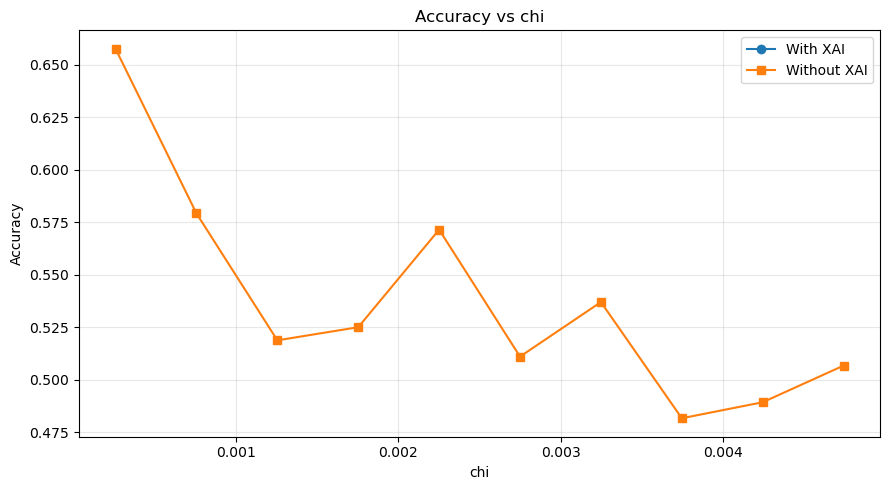

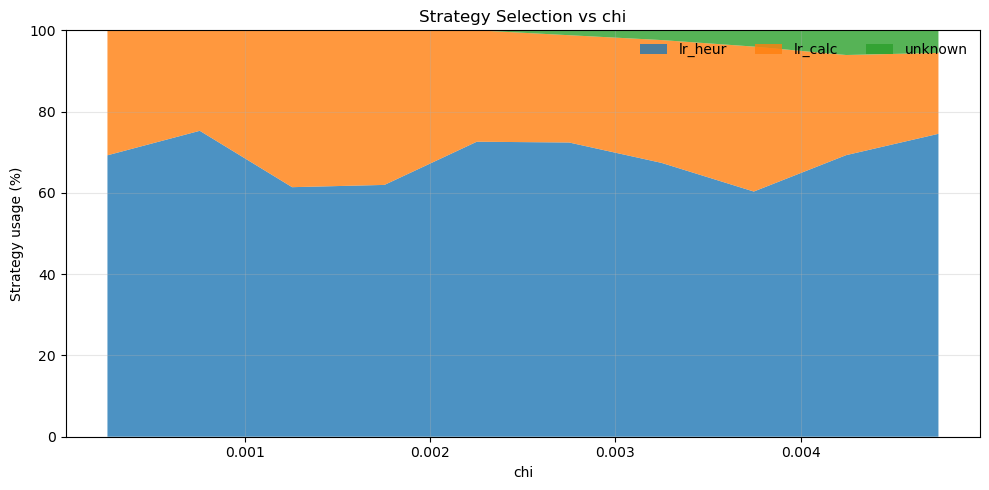


💾 Saved:
  - ./models_meta/eval_outputs\meta_eval_results.csv


In [25]:
# ===== meta_eval.py =====
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from gymnasium.wrappers import TimeLimit

# You must import your own project objects:
# from your_project.meta_env import MetaRouterEnv
# from your_project.strategies import HeadlessLRCalcPolicy, HeadlessLRHeurPolicy, HeadlessDTPolicy, _make_memory
# from your_project.loaders import ai_data_loader2, ai_data_loader3, ai_data_loader4
# from your_project.explainers import lr_exp2, lr_exp3, lr_exp4


# ---------- Eval Env: same obs/action layout; controlled cogs ----------
class MetaRouterEval(MetaRouterEnv):
    """
    Evaluation env for MetaRouterEnv that preserves the training observation space
    but lets you fix any subset of episode-varying cog params via eval_overrides.
    If sample_remaining=False, ranged params not overridden use the midpoint.
    """
    def __init__(
        self,
        *,
        training_cog_params: dict,
        eval_overrides: dict = None,
        sample_remaining: bool = True,
        **base_kwargs,
    ):
        # Parent expects 'training_cog_params' under 'training_cog_params' name:
        super().__init__(training_cog_params=training_cog_params, **base_kwargs)
        self.eval_overrides = dict(eval_overrides or {})
        self.sample_remaining = bool(sample_remaining)

    def _choose_value_from_range(self, lo: float, hi: float, rng):
        if self.sample_remaining:
            return float(rng.uniform(lo, hi))
        return float(0.5 * (lo + hi))

    def reset(self, seed=None, options=None):
        # Let parent build shapes/dataset/schedules first
        super().reset(seed=seed, options=options)
        rng = np.random.default_rng(seed)

        # set the condition again
        self.condition = "LR"

        # Rebuild episode cogs deterministically/with overrides, preserving schema
        new_cogs = {}
        for k, v in (self.cog_cfg or {}).items():
            # Override wins
            if k in self.eval_overrides:
                ov = self.eval_overrides[k]
                new_cogs[k] = float(ov) if isinstance(ov, (int, float)) else ov
                continue

            # Scalars (incl. strings like "l2") pass through
            if isinstance(v, (int, float, str)):
                new_cogs[k] = v if isinstance(v, str) else float(v)
                continue

            # Ranges → sample or midpoint
            if isinstance(v, (list, tuple)) and len(v) == 2:
                lo, hi = float(v[0]), float(v[1])
                new_cogs[k] = self._choose_value_from_range(lo, hi, rng)
                continue

            new_cogs[k] = v

        # Replace parent-sampled cogs with these and reset strategies once more
        self.episode_cogs = new_cogs
        shared = dict(
            rng=rng,
            with_xai_schedule=self.with_xai,
            perm=self.perm,
            inv_perm=self.inv_perm,
            episode_cogs=self.episode_cogs,
            dataset_id=self.dataset_idx
        )
        for s in self.strategies.values():
            s.reset(**shared)

        # Return a fresh obs that reflects any changed params
        return self._obs(), {}


# ---------- Strategy-factory used both for eval and training ----------
def build_strategies_for_eval(training_cog_params: dict, ddm_a_bins: int = 3):
    """
    Build headless strategies (load their trained PPOs inside).
    Adjust model paths as needed.
    """
    strategies = {}

    calc = HeadlessLRCalcPolicy(
        model_path="./model_calculation/simple_chi_model",
        lr_exps={1: lr_exp1, 2: lr_exp2, 3: lr_exp3, 4: lr_exp4},  # match dataset/model
        memory_factory=_make_memory,
        training_cog_params=training_cog_params,
        ddm_a_bins=ddm_a_bins,
    )
    strategies["lr_calc"] = calc

    heur = HeadlessLRHeurPolicy(
        model_path="./model_heuristic/simple_chi_model",
        lr_exps={1: lr_exp1, 2: lr_exp2, 3: lr_exp3, 4: lr_exp4},  # match dataset/model
        memory_factory=_make_memory,
        training_cog_params=training_cog_params,
        ddm_a_bins=ddm_a_bins,
        heuristic_kwargs={"num_samples": 64, "K_top": 3},
    )
    strategies["lr_heur"] = heur

    dt = HeadlessDTPolicy(
        model_path="./model_dt/simple_chi_model.zip",
        dt_exps={1: dt_exp1, 2: dt_exp2, 3: dt_exp3, 4: dt_exp4},  # match dataset/model
        memory_factory=_make_memory,
        training_cog_params=training_cog_params,
        ddm_a_bins=ddm_a_bins,
        forbid_read_without_xai=True,
        dt_kwargs={"n_mc": 64, "topk_k": 3, "refresh_prob_cap": 1.0},
    )
    strategies["dt"] = dt

    # Example DT (if you have it)
    # dt = HeadlessDTPolicy(
    #     model_path="./models_dt/dt_agent.zip",
    #     dt_exp=dt_exp2,
    #     memory_factory=_make_memory,
    #     training_cog_params=training_cog_params,
    # )
    # strategies["dt"] = dt

    return strategies


# ---------- Evaluation runner ----------
def evaluate_meta_model(
    *,
    model_path: str,
    training_cog_params: dict,
    n_episodes: int = 100,
    eval_overrides: dict = None,
    sample_remaining: bool = True,
    ddm_a_bins: int = 3,
    render_plots: bool = True,
):
    # Load meta model
    model = PPO.load(model_path)

    # Build eval env (single env; deterministic meta-policy)
    env = MetaRouterEval(
        strategies=build_strategies_for_eval(training_cog_params, ddm_a_bins=ddm_a_bins),
        ai_dataset_loaders={2: ai_data_loader2},
        training_cog_params=training_cog_params,  # preserves obs space
        instances_per_episode=40,
        max_features=6,
        xai_trial_ratio=0.5,
        shuffle_features=True,
        eval_overrides=eval_overrides or {},
        sample_remaining=sample_remaining,
    )

    results = {
        "chi": [],
        "with_xai": [],
        "strategy": [],            # <-- strategy name chosen by meta
        "prob_correct": [],
        "pred_time": [],
        "reward": [],
        "correct": [],
    }

    # Track varied cogs for analysis (same approach as your LR eval)
    varied_keys = [k for k, v in training_cog_params.items()
                   if isinstance(v, (list, tuple)) and len(v) == 2]
    for k in varied_keys:
        results[f"cog_{k}"] = []

    print(f"🔍 Evaluating meta model for {n_episodes} episodes...")

    for ep in range(n_episodes):
        obs, info = env.reset()
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = bool(terminated or truncated)

            # Log
            results["chi"].append(info.get("chi", getattr(env, "chi", 0.0)))
            results["with_xai"].append(info.get("with_xai", info.get("with_xai_trial", False)))
            results["strategy"].append(info.get("strategy", "unknown"))
            results["prob_correct"].append(info.get("prob_correct", 0.0))
            results["pred_time"].append(info.get("pred_time", 0.0))
            results["reward"].append(float(reward))
            results["correct"].append(1.0 if info.get("prob_correct", 0.0) > 0.5 else 0.0)

            cog = info.get("episode_cogs", info.get("cog_params", {}))
            for k in varied_keys:
                results[f"cog_{k}"].append(cog.get(k, np.nan))

        if (ep + 1) % 10 == 0:
            print(f"  • Completed {ep + 1}/{n_episodes} episodes")

    # Tidy arrays
    for k, v in list(results.items()):
        if isinstance(v, list):
            results[k] = np.asarray(v)

    # ----- Summary -----
    print("\n" + "=" * 50)
    print("📈 META EVALUATION SUMMARY")
    print("=" * 50)
    print(f"Mean Accuracy: {np.mean(results['correct']):.3f}")
    print(f"Mean Reward  : {np.mean(results['reward']):.3f}")
    print(f"Mean χ       : {np.mean(results['chi']):.4f}")

    # Strategy counts
    uniq, counts = np.unique(results["strategy"], return_counts=True)
    total = results["strategy"].size
    print("\nStrategy usage:")
    for s, c in zip(uniq, counts):
        print(f"  - {s:>10s}: {c} ({100.0 * c / total:.1f}%)")

    # Plots
    if render_plots:
        plot_accuracy_vs(results, by="chi", n_bins=10)
        plot_strategy_usage_by_x(results, by="chi", n_bins=10, as_stacked=True)

    return results, env


# ---------- Plot helpers ----------
def _values_and_bins(results: dict, by="chi", n_bins=10):
    if by == "chi":
        xvals = results["chi"]
    else:
        key = f"cog_{by}"
        if key not in results:
            raise ValueError(
                f"'{by}' not tracked. Use 'chi' or one of: "
                f"{[k.removeprefix('cog_') for k in results.keys() if k.startswith('cog_')]}"
            )
        xvals = results[key]

    xmin, xmax = float(np.nanmin(xvals)), float(np.nanmax(xvals))
    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin == xmax:
        xmin, xmax = xmin - 1e-6, xmax + 1e-6
    bins = np.linspace(xmin, xmax, n_bins + 1)
    return xvals, bins


def plot_accuracy_vs(results: dict, by="chi", n_bins=10):
    xvals, bins = _values_and_bins(results, by=by, n_bins=n_bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    correct = np.asarray(results["correct"], dtype=float)
    with_xai = np.asarray(results["with_xai"], dtype=bool)

    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    for flag, label, marker in [(True, "With XAI", "o"), (False, "Without XAI", "s")]:
        y = []
        for i in range(n_bins):
            mask = (with_xai == flag) & (xvals >= bins[i]) & (xvals < bins[i+1])
            y.append(np.nanmean(correct[mask]) if np.any(mask) else np.nan)
        ax.plot(bin_centers, y, marker=marker, linestyle="-", label=label)
    ax.set_xlabel(by if by == "chi" else f"{by} (cog param)")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Accuracy vs {by}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_strategy_usage_by_x(results: dict, by="chi", n_bins=10, as_stacked=True):
    """
    Show strategy usage vs an x-axis (χ by default). If as_stacked=True, renders
    a stacked area chart of % usage per bin; otherwise line plot per strategy.
    """
    xvals, bins = _values_and_bins(results, by=by, n_bins=n_bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    strategies = results["strategy"].astype("U")  # array of strings

    # Collect unique strategies in stable order of first appearance
    unique_strats = []
    seen = set()
    for s in strategies:
        if s not in seen:
            unique_strats.append(s)
            seen.add(s)
    S = len(unique_strats)

    # Compute % per bin per strategy
    pct = np.zeros((n_bins, S), dtype=float)
    for i in range(n_bins):
        # include right edge on last bin
        in_bin = (xvals >= bins[i]) & ((xvals < bins[i+1]) if i < n_bins-1 else (xvals <= bins[i+1]))
        total = np.sum(in_bin)
        if total == 0:
            pct[i, :] = np.nan
            continue
        for j, s in enumerate(unique_strats):
            pct[i, j] = 100.0 * np.sum(in_bin & (strategies == s)) / total

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    if as_stacked:
        # Stacked area chart
        ax.stackplot(bin_centers, *[pct[:, j] for j in range(S)], labels=unique_strats, alpha=0.8)
        ax.set_ylabel("Strategy usage (%)")
    else:
        for j, s in enumerate(unique_strats):
            ax.plot(bin_centers, pct[:, j], marker="o", label=s)
        ax.set_ylabel("Usage (%)")

    ax.set_xlabel(by if by == "chi" else f"{by} (cog param)")
    ax.set_title(f"Strategy Selection vs {by}")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=min(3, S), frameon=False)
    plt.tight_layout()
    plt.show()


# ---------- Example run ----------
if __name__ == "__main__":
    # Use the exact dict you trained with
    # training_cog_params = {
    #     "retrieval_threshold": [-1.0, 0.5],
    #     "latency_factor": [0.0, 0.2],
    #     "T_enc": [0.5, 3.0],
    #     "T_op": [1.5, 3.0],
    #     "ddm_a": [0.8, 1.3],
    #     "ddm_s": [0.7, 1.1],
    #     "ddm_Tnd": 0.30,
    #     "ddm_norm": "l2",
    #     "compute_sf": 2.0,
    #     "lapse": 0.05,
    #     "chi": [0.0, 0.01],
    # }

    results, eval_env = evaluate_meta_model(
        model_path="./models_meta/best/best_model.zip",
        training_cog_params=training_cog_params,
        n_episodes=200,
        eval_overrides={
            # Example: lock certain params for stable eval
            # "retrieval_threshold": -1.0,
            # "latency_factor": 0.0,
            # "T_enc": 1.0,
            "ddm_s": 0.4,
        },
        sample_remaining=False,   # midpoints for unspecified ranged params
        ddm_a_bins=3,
        render_plots=True,

    )

    # Save flat results (one row per trial)
    out_dir = "./models_meta/eval_outputs"
    os.makedirs(out_dir, exist_ok=True)
    pd.DataFrame({
        k: (v.tolist() if isinstance(v, np.ndarray) else v)
        for k, v in results.items()
    }).to_csv(os.path.join(out_dir, "meta_eval_results.csv"), index=False)

    print("\n💾 Saved:")
    print(f"  - {os.path.join(out_dir, 'meta_eval_results.csv')}")


C:\Users\Louth\AppData\Local\Temp\ipykernel_16092\387813336.py:247: RuntimeWarning: All-NaN slice encountered
  xmin, xmax = float(np.nanmin(xvals)), float(np.nanmax(xvals))


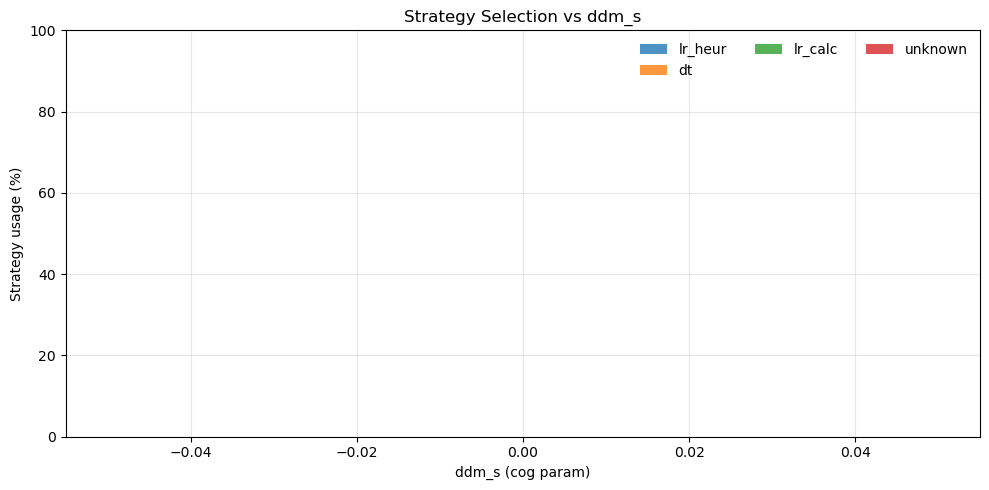

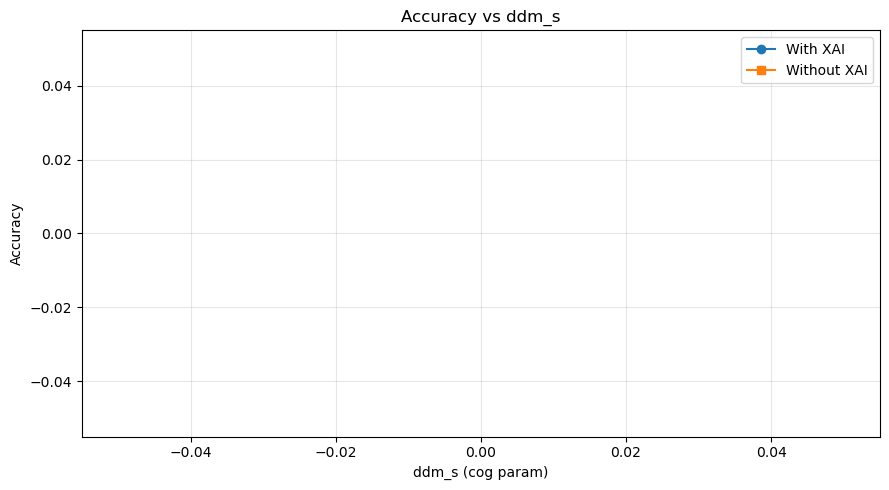

In [17]:
by_param = "ddm_s"
plot_strategy_usage_by_x(results=results, by=by_param, n_bins=10, as_stacked=True)
plot_accuracy_vs(results=results, by=by_param, n_bins=10)